# Rossmann - Time Series Analysis and Forecasting with Prophet

![Rossmann - Time Series Analysis and Forecasting with Prophet](rossmann.png)

In [3]:
import warnings
warnings.filterwarnings("ignore")

# loading packages
# basic + dates 
import numpy as np
import pandas as pd
from datetime import datetime

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns # advanced vizs
%matplotlib inline

# statistics
from statsmodels.distributions.empirical_distribution import ECDF

# time series analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# prophet by Facebook
from prophet import Prophet

In [5]:
# importing train data to learn
train = pd.read_csv("train.csv", 
                    parse_dates = True, low_memory = False, index_col = 'Date')

# additional store data
store = pd.read_csv("store.csv", 
                    low_memory = False)
# time series as indexes
train.index

DatetimeIndex(['2015-07-31', '2015-07-31', '2015-07-31', '2015-07-31',
               '2015-07-31', '2015-07-31', '2015-07-31', '2015-07-31',
               '2015-07-31', '2015-07-31',
               ...
               '2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-01', '2013-01-01'],
              dtype='datetime64[ns]', name='Date', length=1017209, freq=None)

### Exploratory Data Analysis

In [6]:
# first glance at the train set: head and tail
print("In total: ", train.shape)
train.head(5)

In total:  (1017209, 8)


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-31,2,5,6064,625,1,1,0,1
2015-07-31,3,5,8314,821,1,1,0,1
2015-07-31,4,5,13995,1498,1,1,0,1
2015-07-31,5,5,4822,559,1,1,0,1


In [8]:
train.dtypes

Store             int64
DayOfWeek         int64
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
dtype: object

In [9]:
train.describe

<bound method NDFrame.describe of             Store  DayOfWeek  Sales  Customers  Open  Promo StateHoliday  \
Date                                                                       
2015-07-31      1          5   5263        555     1      1            0   
2015-07-31      2          5   6064        625     1      1            0   
2015-07-31      3          5   8314        821     1      1            0   
2015-07-31      4          5  13995       1498     1      1            0   
2015-07-31      5          5   4822        559     1      1            0   
...           ...        ...    ...        ...   ...    ...          ...   
2013-01-01   1111          2      0          0     0      0            a   
2013-01-01   1112          2      0          0     0      0            a   
2013-01-01   1113          2      0          0     0      0            a   
2013-01-01   1114          2      0          0     0      0            a   
2013-01-01   1115          2      0          0     0  

In [11]:
# data extraction
train['Year'] = train.index.year
train['Month'] = train.index.month
train['Day'] = train.index.day
train['WeekOfYear'] = train.index.isocalendar().week

# adding new variable
train['SalePerCustomer'] = train['Sales'] / train['Customers']
train['SalePerCustomer'].describe()


count    844340.000000
mean          9.493619
std           2.197494
min           0.000000
25%           7.895563
50%           9.250000
75%          10.899729
max          64.957854
Name: SalePerCustomer, dtype: float64

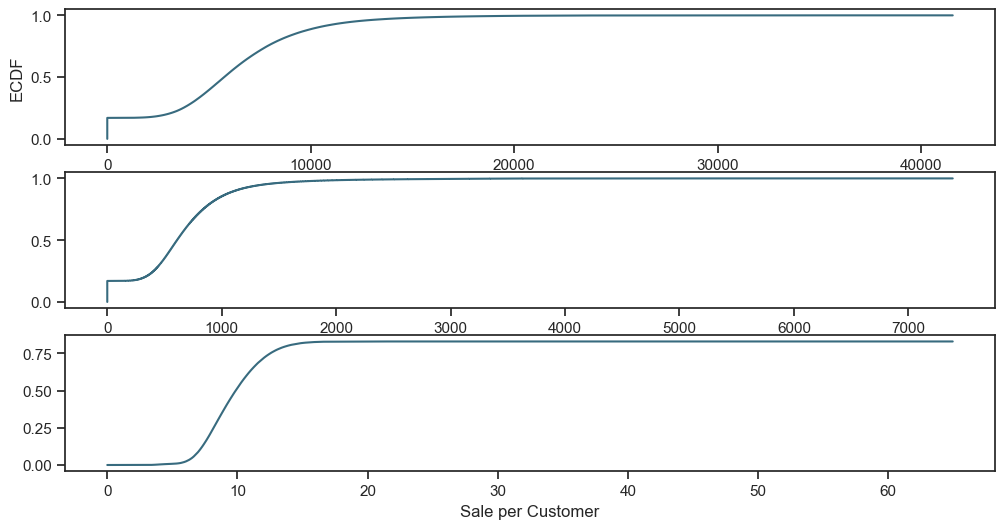

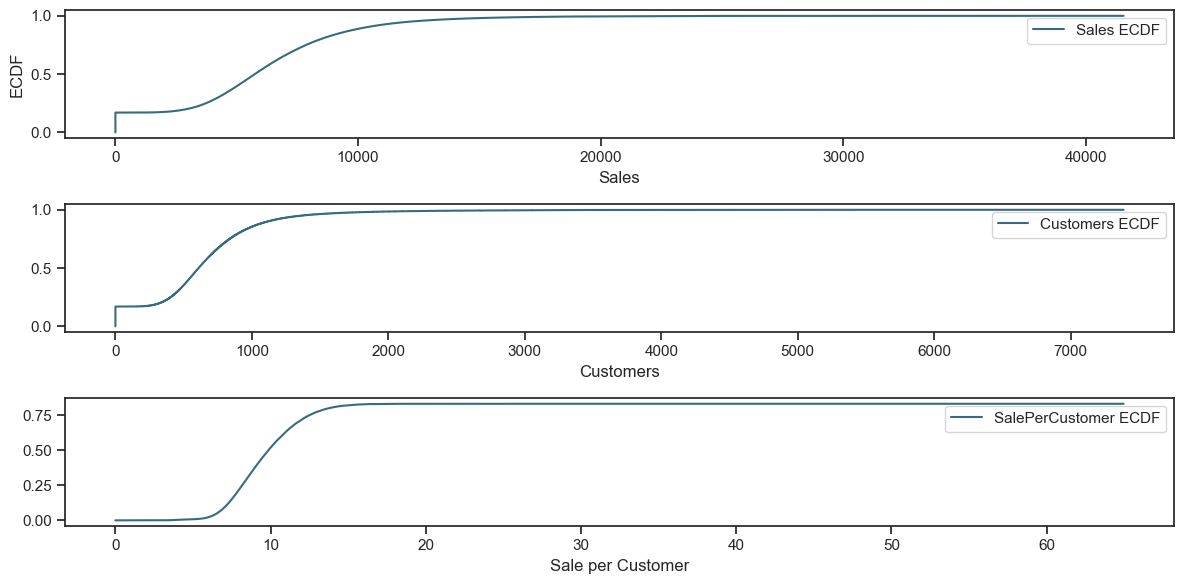

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

sns.set(style="ticks")  # seaborn tarzı
c = '#386B7F'           # grafik rengi

plt.figure(figsize=(12, 6))

# 1️⃣ Sales ECDF
plt.subplot(311)
cdf = ECDF(train['Sales'])
plt.plot(cdf.x, cdf.y, label="Sales ECDF", color=c)
plt.xlabel('Sales'); plt.ylabel('ECDF')
plt.legend()

# 2️⃣ Customers ECDF
plt.subplot(312)
cdf = ECDF(train['Customers'])
plt.plot(cdf.x, cdf.y, label="Customers ECDF", color=c)
plt.xlabel('Customers')
plt.legend()

# 3️⃣ SalePerCustomer ECDF
plt.subplot(313)
cdf = ECDF(train['SalePerCustomer'])
plt.plot(cdf.x, cdf.y, label="SalePerCustomer ECDF", color=c)
plt.xlabel('Sale per Customer')
plt.legend()

plt.tight_layout()
plt.show();

### Missing values:
Closed stores and zero sales stores

Eksik değerler:
Kapalı mağazalar ve sıfır satış mağazaları

In [14]:
# closed stores
train[(train.Open == 0) & (train.Sales == 0)].head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear,SalePerCustomer
Date,,,,,,,,,,,,,
2015-07-31,292,5,0,0,0,1,0,1,2015,7,31,31,3.215949
2015-07-31,876,5,0,0,0,1,0,1,2015,7,31,31,3.442387
2015-07-30,292,4,0,0,0,1,0,1,2015,7,30,31,3.581798
2015-07-30,876,4,0,0,0,1,0,1,2015,7,30,31,3.700326
2015-07-29,292,3,0,0,0,1,0,1,2015,7,29,31,3.806407


In [15]:
# opened stores with zero sales
zero_sales = train[(train.Open != 0) & (train.Sales == 0)]
print("In total: ", zero_sales.shape)
zero_sales.head(5)

In total:  (142774, 13)


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear,SalePerCustomer
Date,,,,,,,,,,,,,
2015-07-31,1,5,0,0,1,1,0,1,2015,7,31,31,0.000000
2015-07-31,2,5,0,0,1,1,0,1,2015,7,31,31,0.000000
2015-07-31,3,5,0,0,1,1,0,1,2015,7,31,31,2.749075
2015-07-31,4,5,0,0,1,1,0,1,2015,7,31,31,2.752415
2015-07-31,5,5,0,0,1,1,0,1,2015,7,31,31,2.768924


In [16]:
print("Closed stores and days which didn't have any sales won't be counted into the forecasts.")
train = train[(train["Open"] != 0) & (train['Sales'] != 0)]

print("In total: ", train.shape)

Closed stores and days which didn't have any sales won't be counted into the forecasts.
In total:  (701618, 13)


In [18]:
# additional information about the stores
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [19]:
# missing values?
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [20]:
# missing values in CompetitionDistance
store[pd.isnull(store.CompetitionDistance)]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [21]:
# fill NaN with a median value (skewed distribuion)
store['CompetitionDistance'].fillna(store['CompetitionDistance'].median(), inplace = True)

In [22]:
# no promo = no information about the promo?
_ = store[pd.isnull(store.Promo2SinceWeek)]
_[_.Promo2 != 0].shape

(0, 10)

In [23]:
# replace NA's by 0
store.fillna(0, inplace = True)

In [24]:
print("Joining train set with an additional store information.")

# by specifying inner join we make sure that only those observations 
# that are present in both train and store sets are merged together
train_store = pd.merge(train, store, how = 'inner', on = 'Store')

print("In total: ", train_store.shape)
train_store.head()

Joining train set with an additional store information.
In total:  (701618, 22)


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,...,SalePerCustomer,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,47,4,46,8,1,0,0,0,2015,2,...,7.640436,a,c,270.0,4.0,2013.0,1,14.0,2013.0,"Jan,Apr,Jul,Oct"
1,48,4,124,13,1,0,0,0,2015,2,...,7.640436,a,a,1060.0,5.0,2012.0,0,0.0,0.0,0
2,49,4,133,18,1,0,0,0,2015,2,...,7.640437,d,c,18010.0,9.0,2007.0,0,0.0,0.0,0
3,50,4,286,36,1,0,0,0,2015,2,...,7.640439,d,a,6260.0,11.0,2009.0,0,0.0,0.0,0
4,51,4,297,40,1,0,0,0,2015,2,...,7.640449,a,c,10570.0,7.0,2013.0,1,9.0,2011.0,"Jan,Apr,Jul,Oct"


In [25]:
train_store.groupby('StoreType')['Sales'].describe()

,count,mean,std,min,25%,50%,75%,max
StoreType,,,,,,,,
a,380154.0,6929.465888,3048.811449,46.0,4830.00,6347.0,8330.0,25940.0
b,12928.0,6796.438970,3021.026844,660.0,4745.75,6224.5,8136.0,34904.0
c,94125.0,6896.538954,3039.876493,569.0,4792.00,6309.0,8301.0,23723.0
d,214411.0,6987.410707,3056.588065,133.0,4919.00,6414.0,8377.0,23728.0


In [27]:
train_store.groupby('StoreType')[['Customers', 'Sales']].agg(['sum', 'mean', 'count'])

Customers                           Sales                     
                 sum        mean   count         sum         mean   count
StoreType                                                                
a          288647411  759.290737  380154  2634264175  6929.465888  380154
b            9615822  743.798113   12928    87864363  6796.438970   12928
c           71110920  755.494502   94125   649136729  6896.538954   94125
d          164201529  765.826049  214411  1498177717  6987.410707  214411

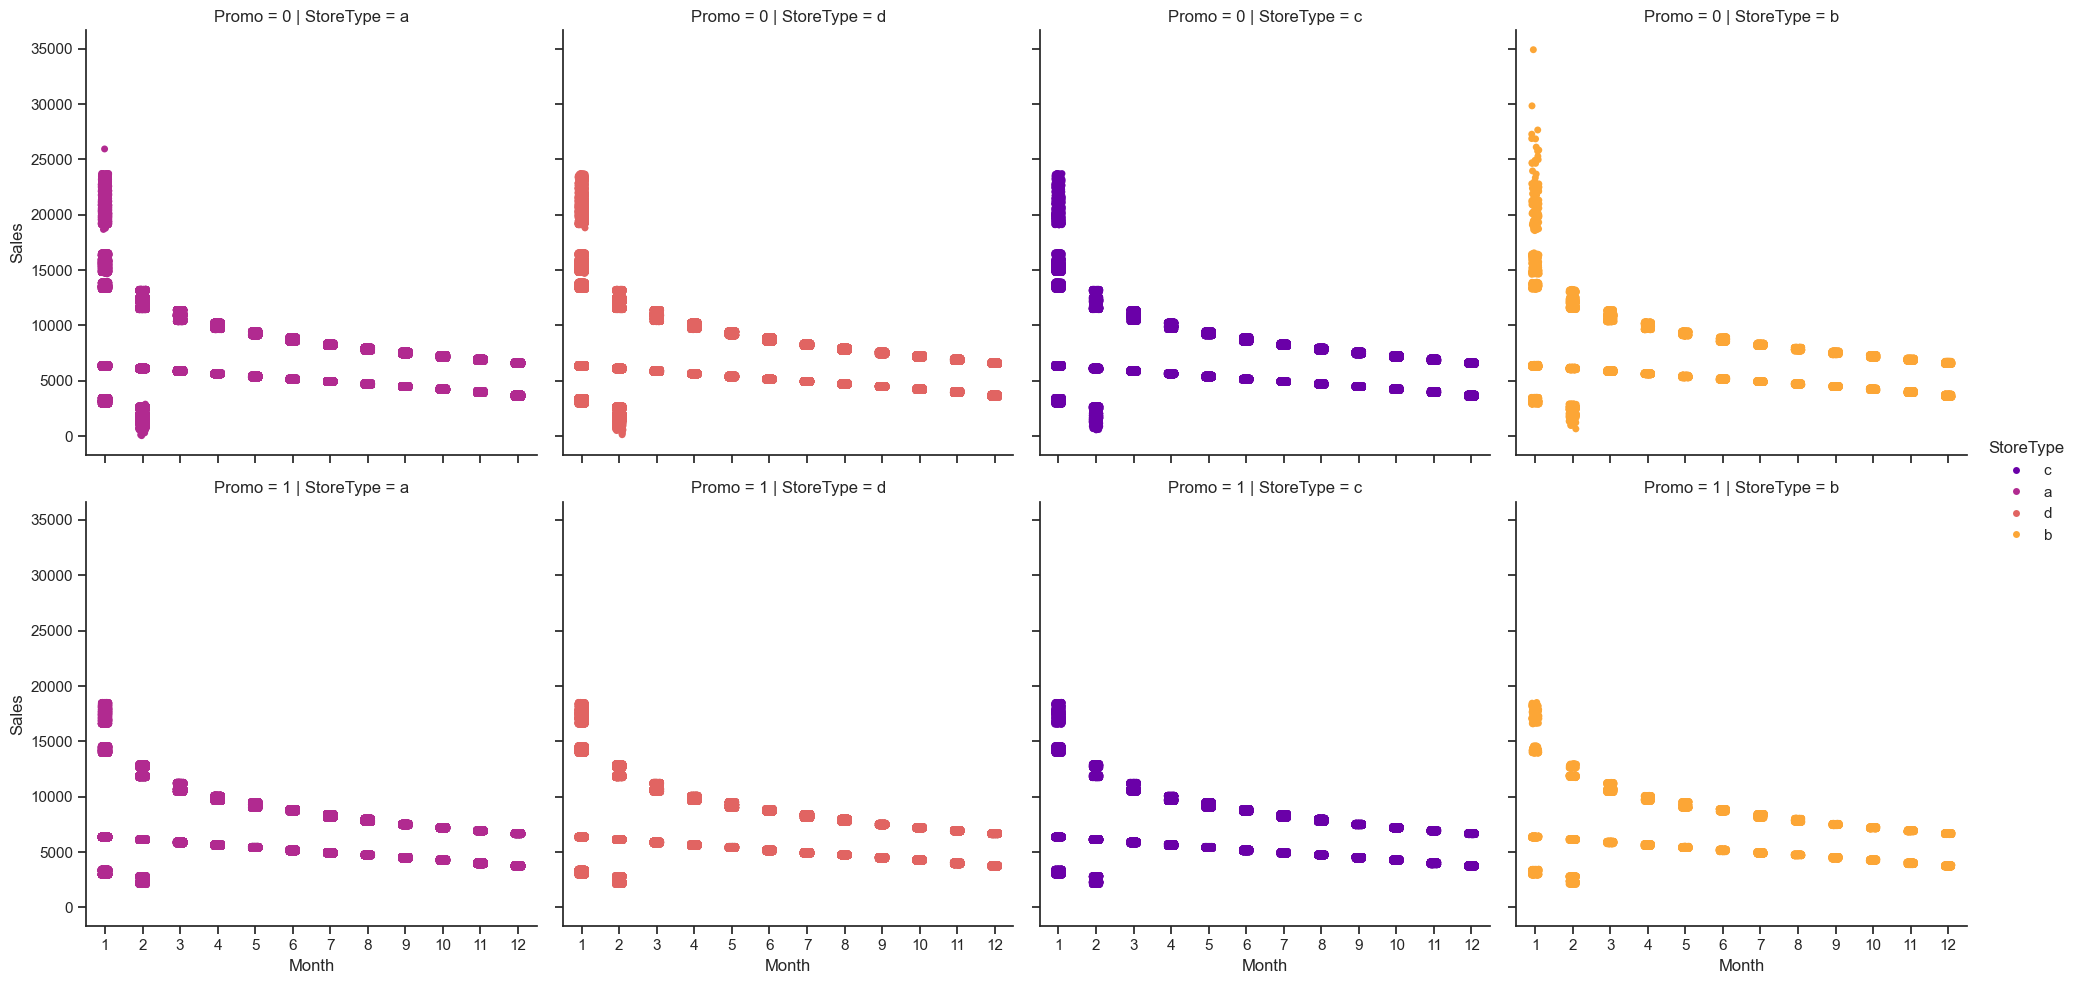

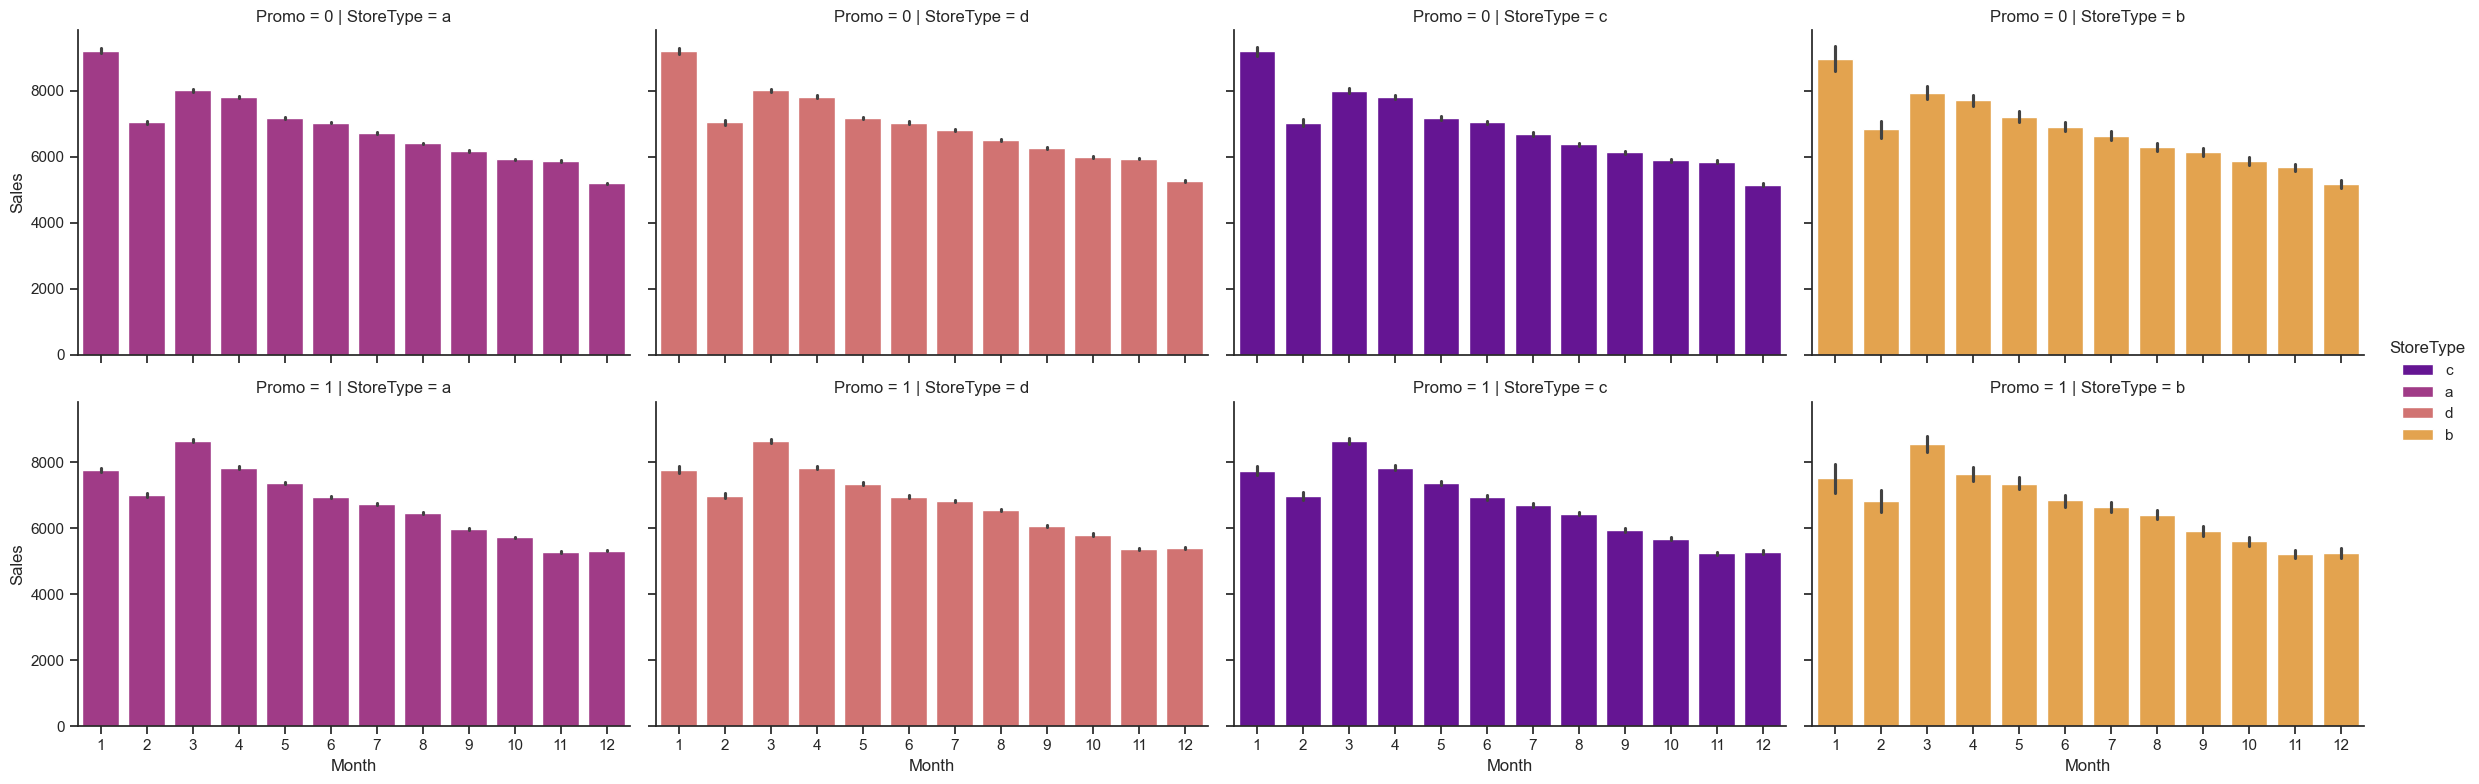

In [30]:
# sales trends
g = sns.catplot(
    data=train_store,
    x='Month',
    y='Sales',
    col='StoreType',
    palette='plasma',
    hue='StoreType',
    row='Promo',
    kind='bar',      # eklemek gerekli, çünkü varsayılan tür yok
    height=4,
    aspect=1.5
)

plt.show()


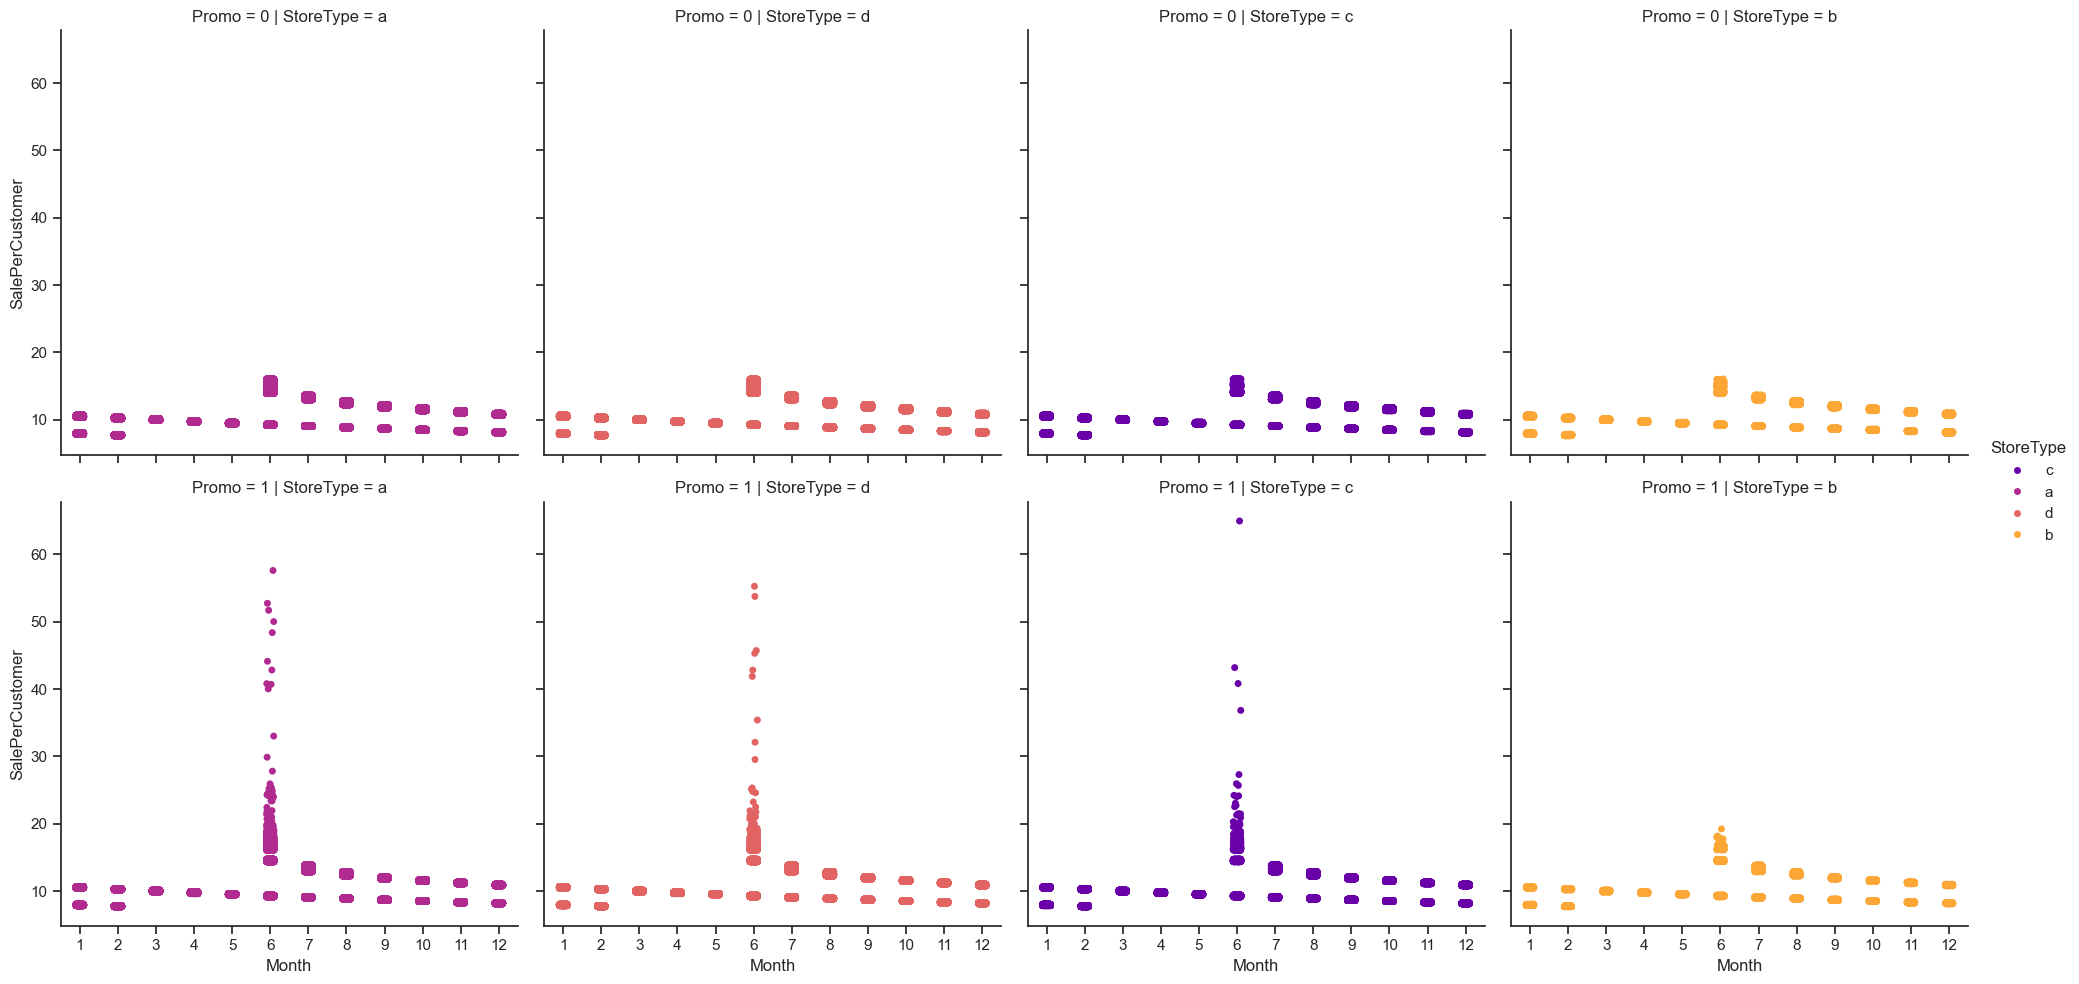

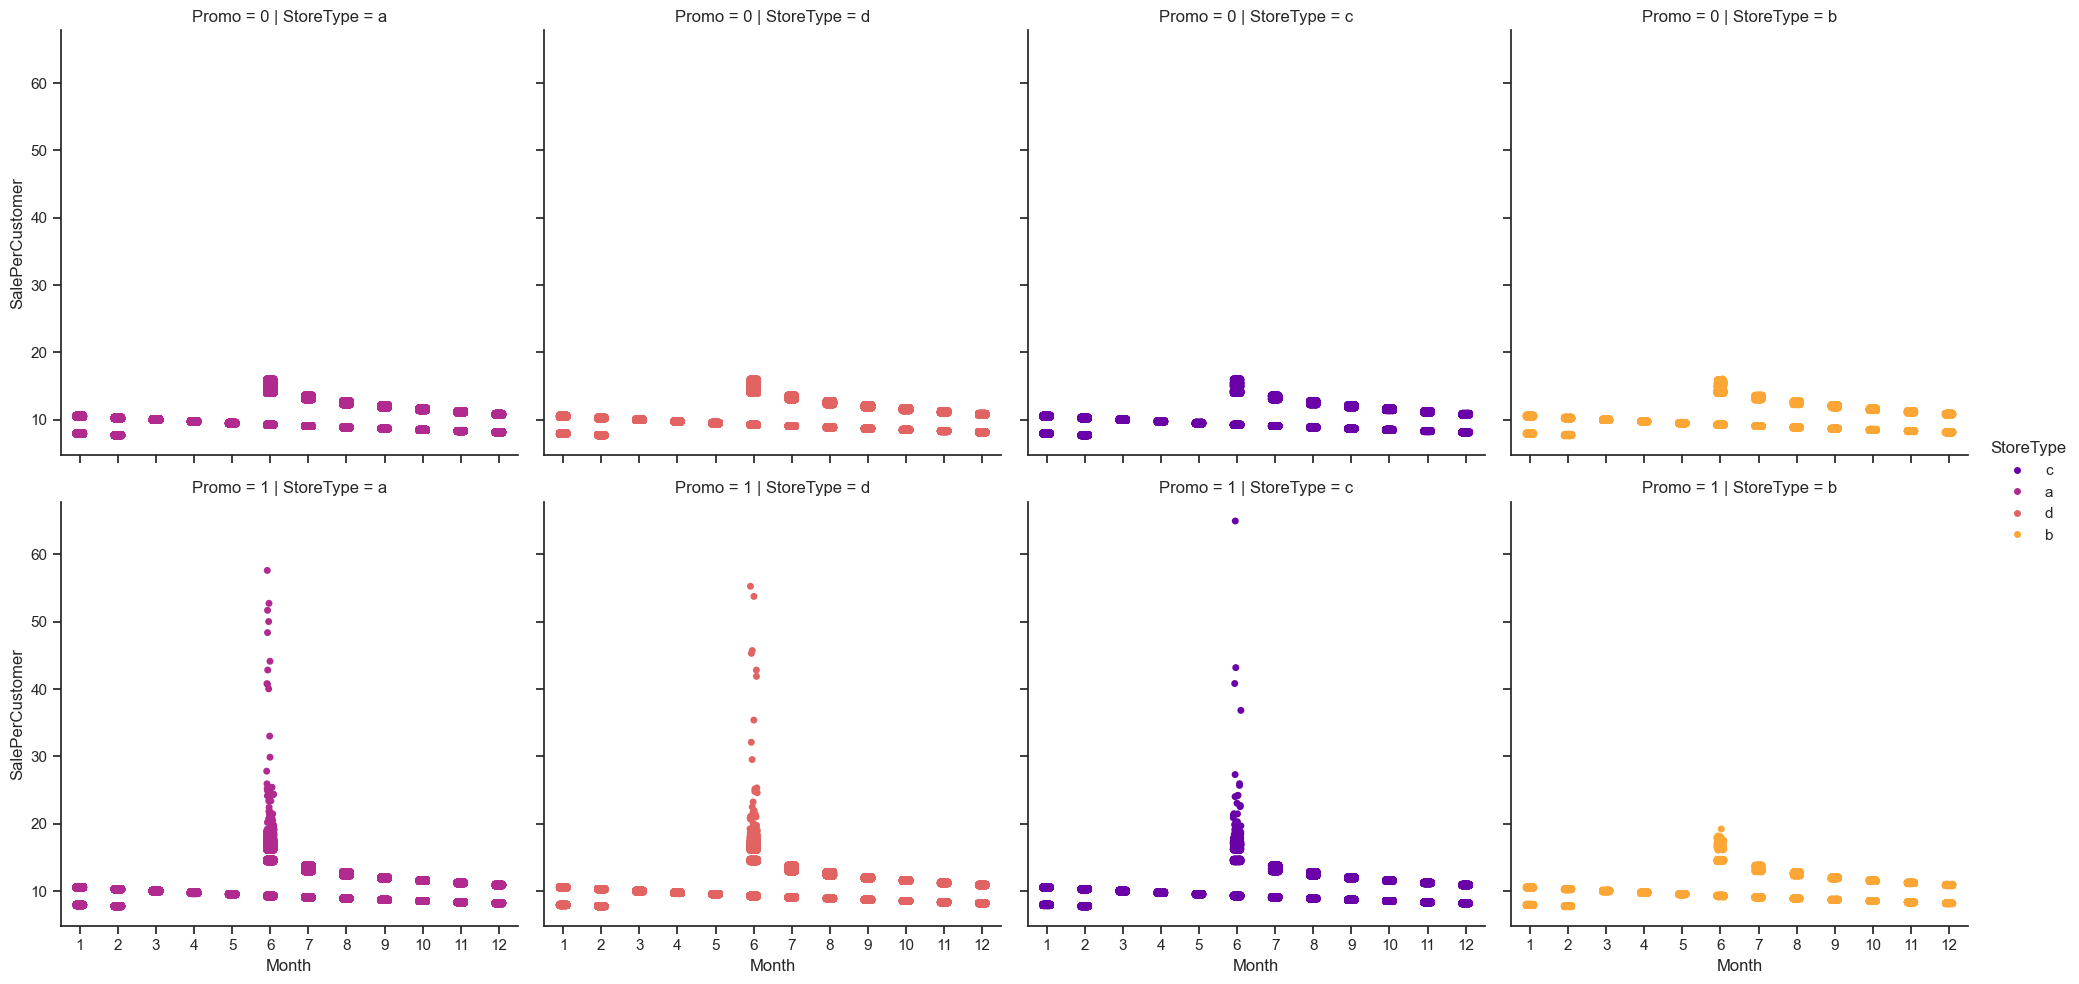

In [33]:
# sale per customer trends
sns.catplot(data = train_store, x = 'Month', y = "SalePerCustomer", 
               col = 'StoreType', # per store type in cols
               palette = 'plasma',
               hue = 'StoreType',
               row = 'Promo', # per promo in the store in rows
               color = c)
plt.show();

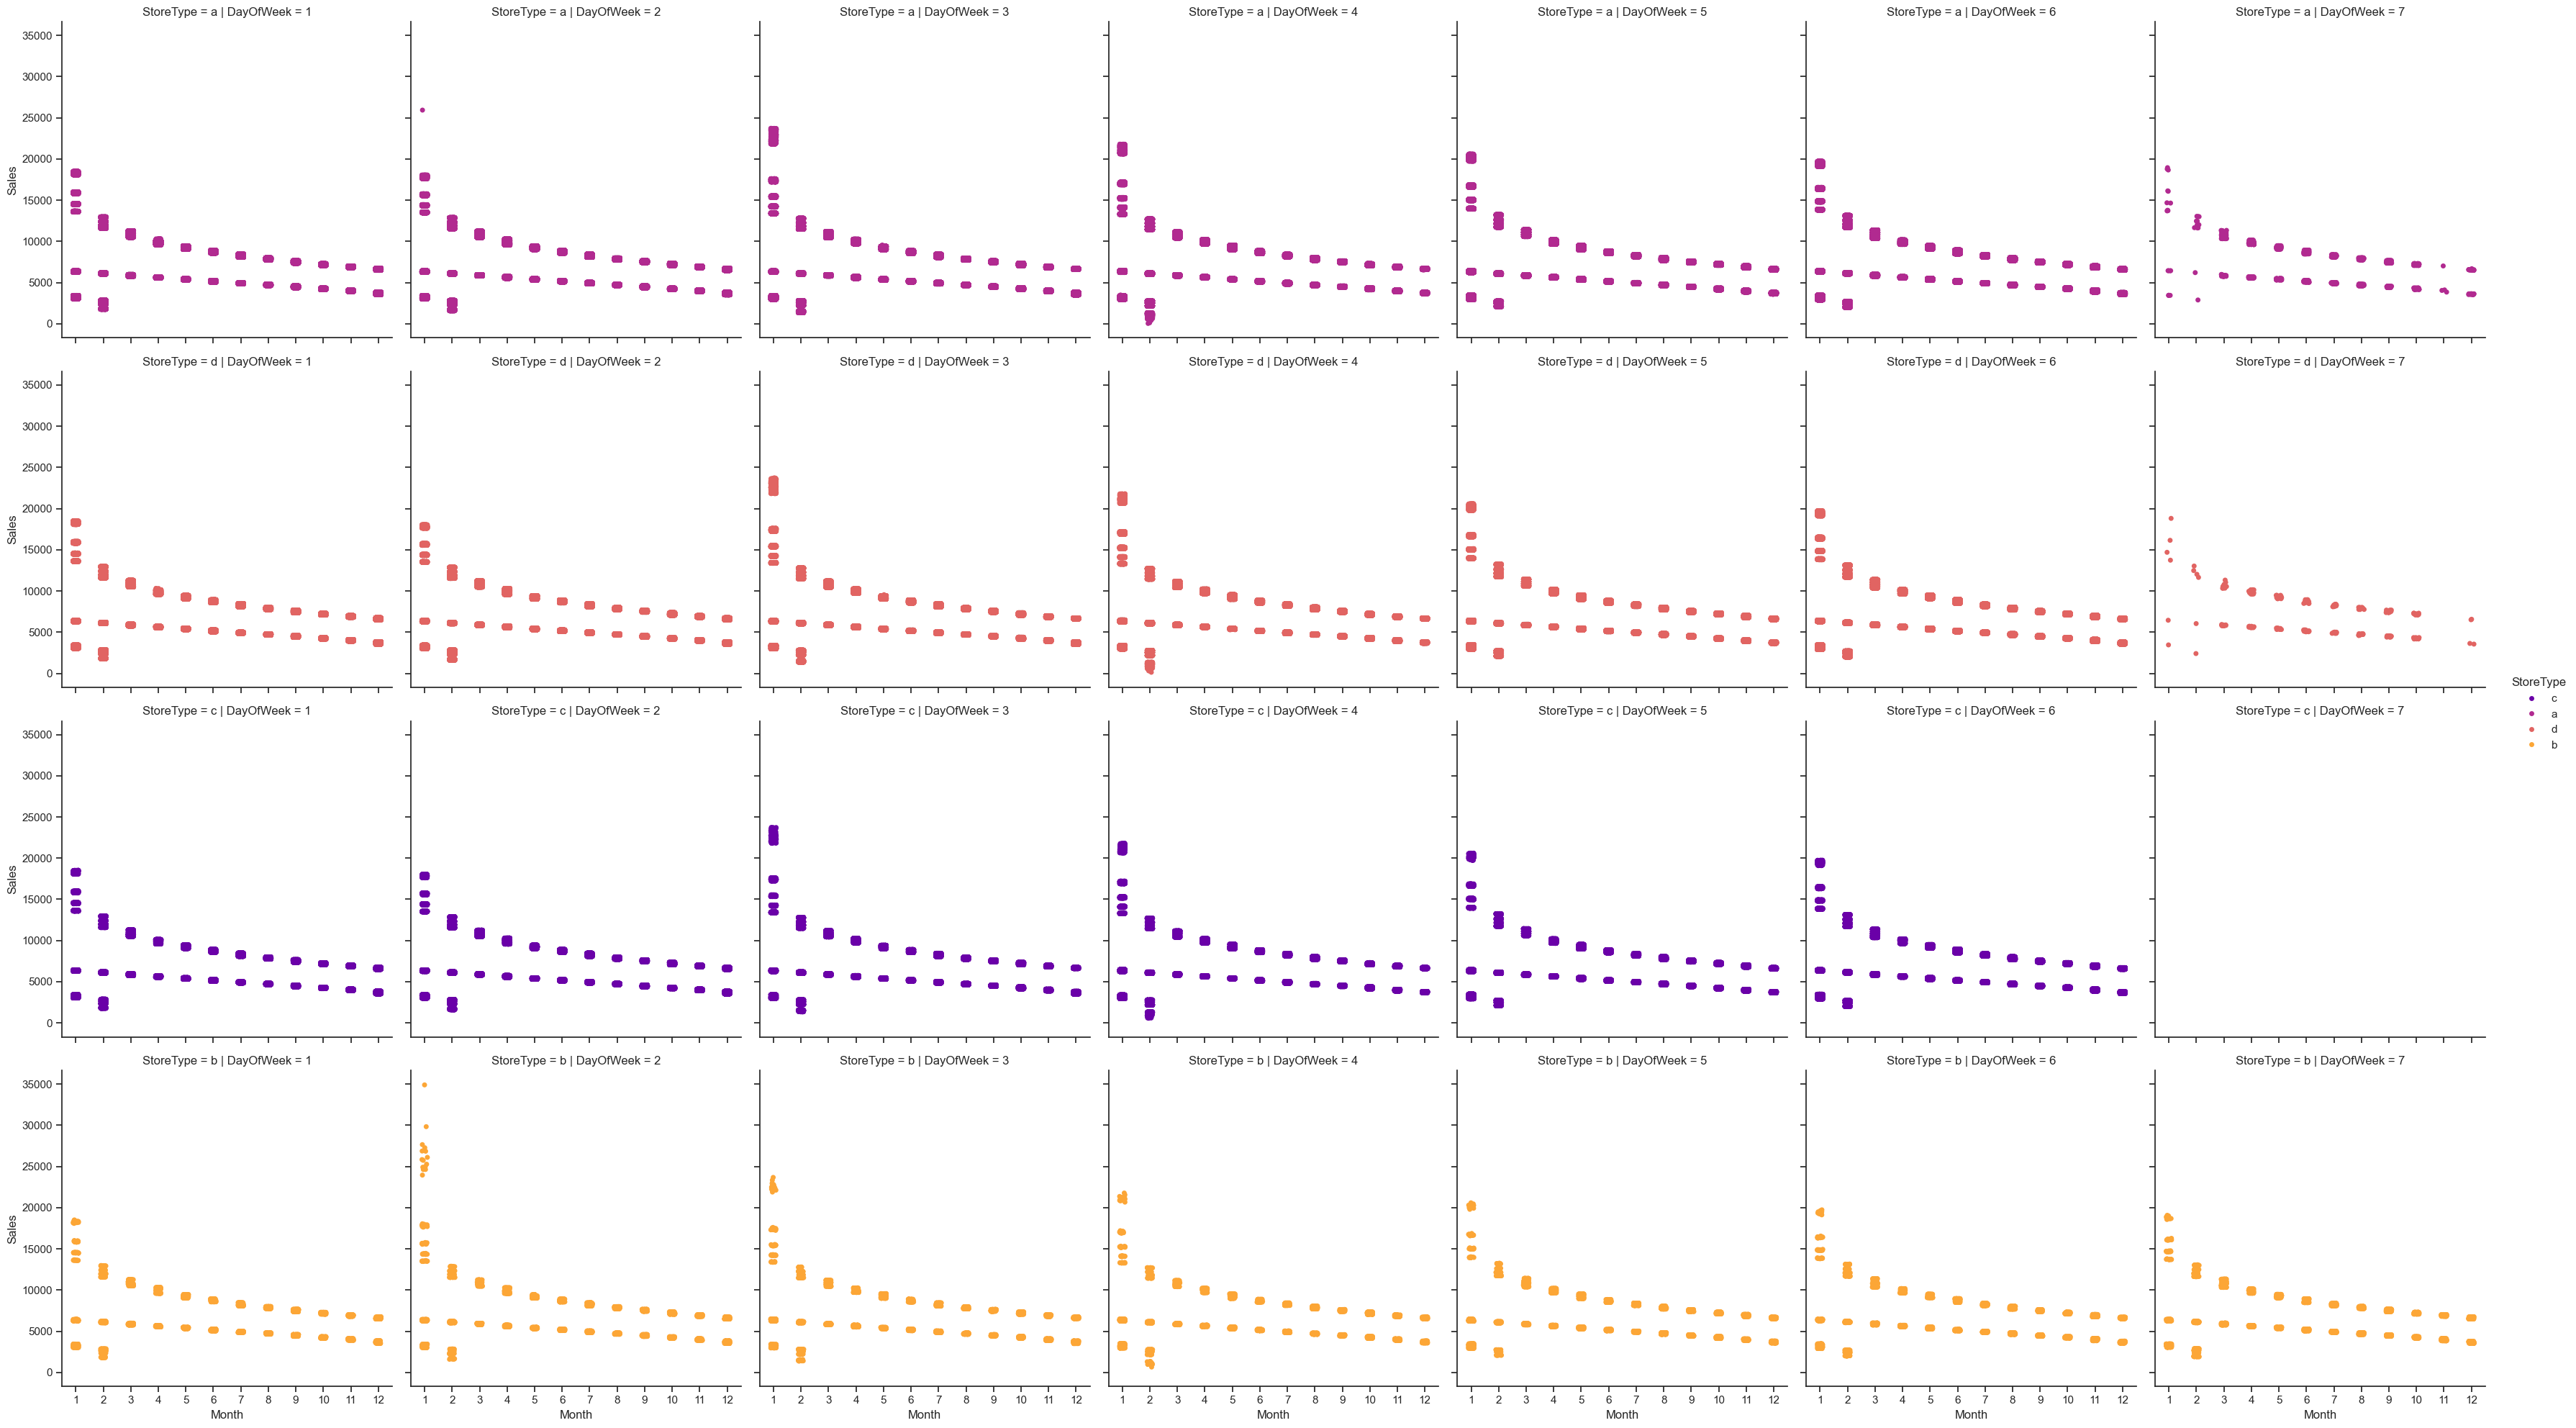

In [34]:
# customers
sns.catplot(data = train_store, x = 'Month', y = "Sales", 
               col = 'DayOfWeek', # per store type in cols
               palette = 'plasma',
               hue = 'StoreType',
               row = 'StoreType', # per store type in rows
               color = c)
plt.show();

In [35]:
# stores which are opened on Sundays
train_store[(train_store.Open == 1) & (train_store.DayOfWeek == 7)]['Store'].unique()

array([  85,  259,  262,  274,  335,  353,  423,  494,  512,  562,  676,
        682,  733,  769,  948, 1081, 1097,  578,  877,  310,  530,  863,
       1099,  122,  453,  732,  209, 1045,  299,  524,  867,  931,  433])

In [36]:
# competition open time (in months)
train_store['CompetitionOpen'] = 12 * (train_store.Year - train_store.CompetitionOpenSinceYear) + \
        (train_store.Month - train_store.CompetitionOpenSinceMonth)
    
# Promo open time
train_store['PromoOpen'] = 12 * (train_store.Year - train_store.Promo2SinceYear) + \
        (train_store.WeekOfYear - train_store.Promo2SinceWeek) / 4.0

# replace NA's by 0
train_store.fillna(0, inplace = True)

# average PromoOpen time and CompetitionOpen time per store type
train_store.loc[:, ['StoreType', 'Sales', 'Customers', 'PromoOpen', 'CompetitionOpen']].groupby('StoreType').mean()

,Sales,Customers,PromoOpen,CompetitionOpen
StoreType,,,,
a,6929.465888,759.290737,12977.295287,7114.725025
b,6796.438970,743.798113,17223.508528,11354.900217
c,6896.538954,755.494502,12193.015363,6743.841742
d,6987.410707,765.826049,10466.321006,9036.862465


### Correlational Analysis

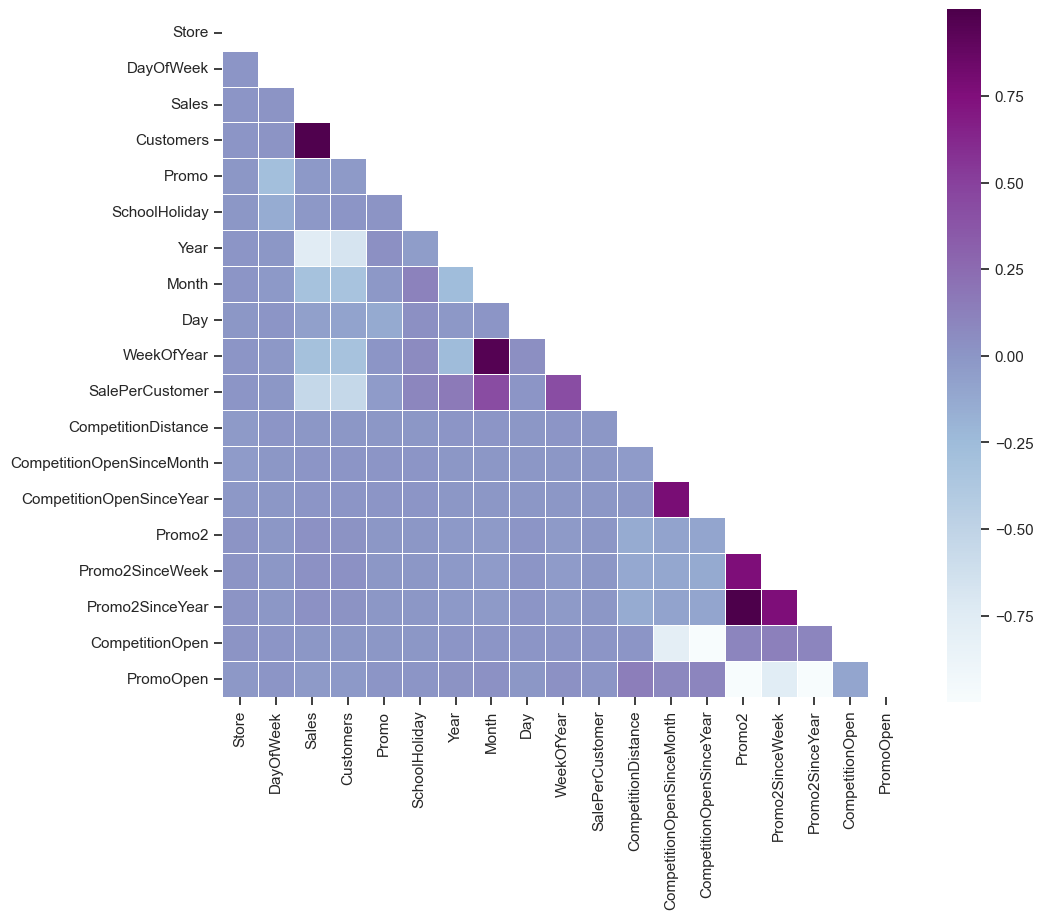

In [38]:
# sadece numerik sütunları al
corr_all = train_store.drop('Open', axis=1).select_dtypes(include=[np.number]).corr()

# maske oluştur
mask = np.zeros_like(corr_all, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# çizim
f, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_all, mask=mask, square=True, linewidths=.5, ax=ax, cmap="BuPu")
plt.show()

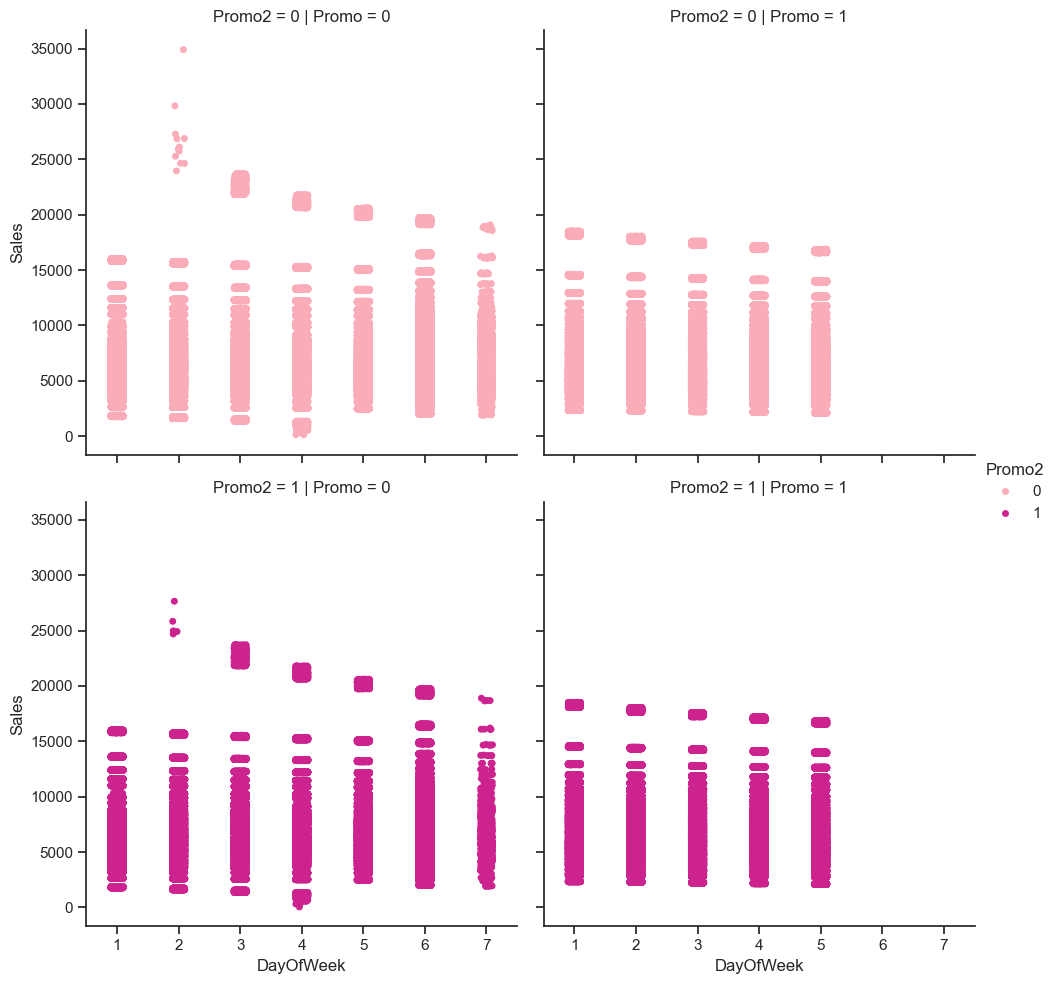

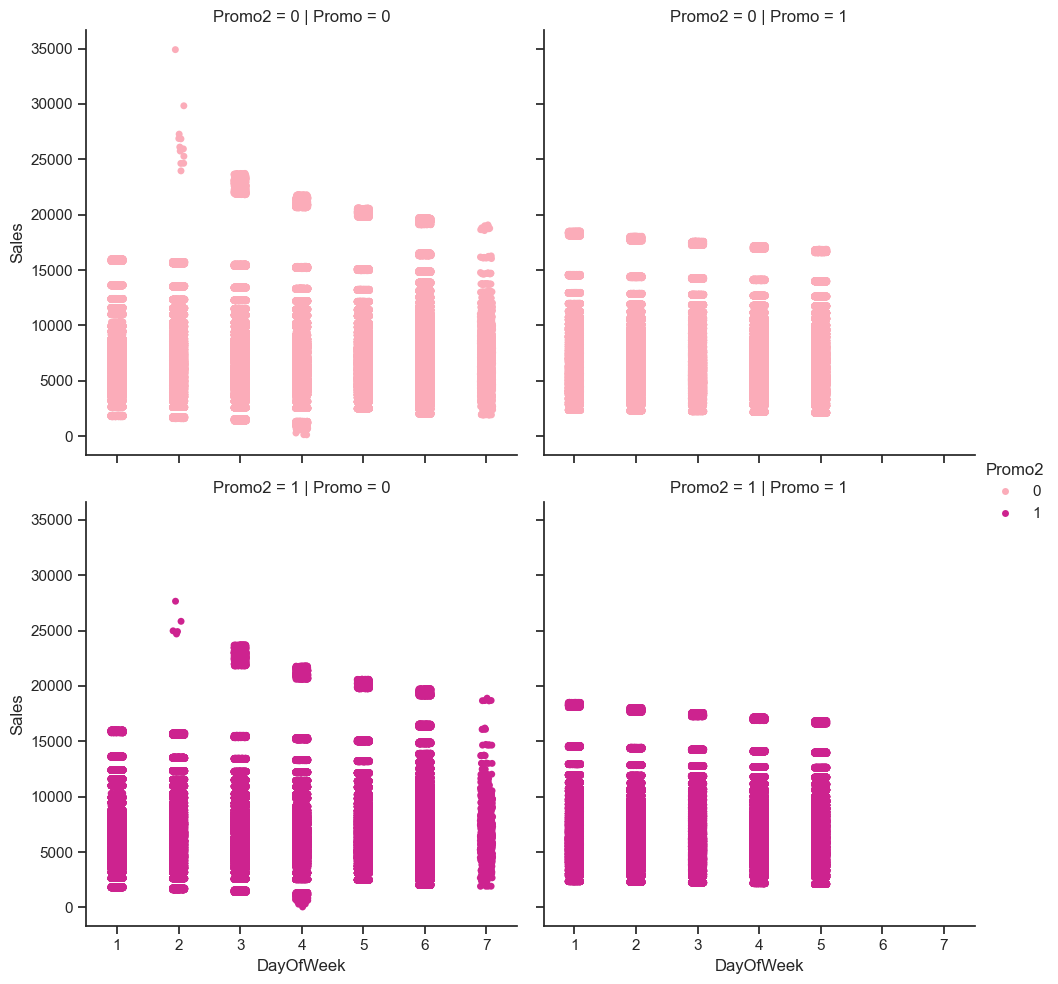

In [41]:
# sale per customer trends
sns.catplot(data = train_store, x = 'DayOfWeek', y = "Sales", 
               col = 'Promo', 
               row = 'Promo2',
               hue = 'Promo2',
               palette = 'RdPu')
plt.show()

### Conclusion of EDA

### Time-Series Analysis per Store Type

### Seasonality

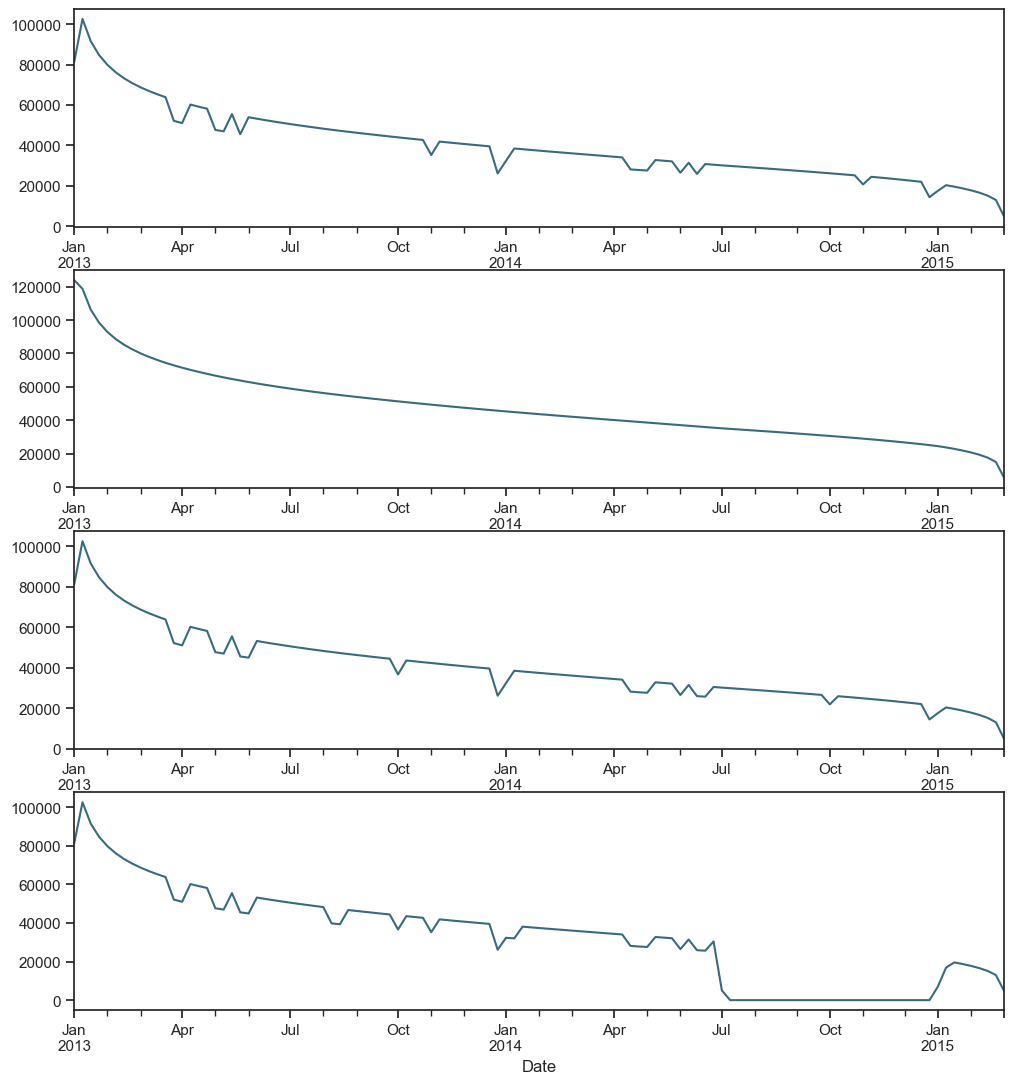

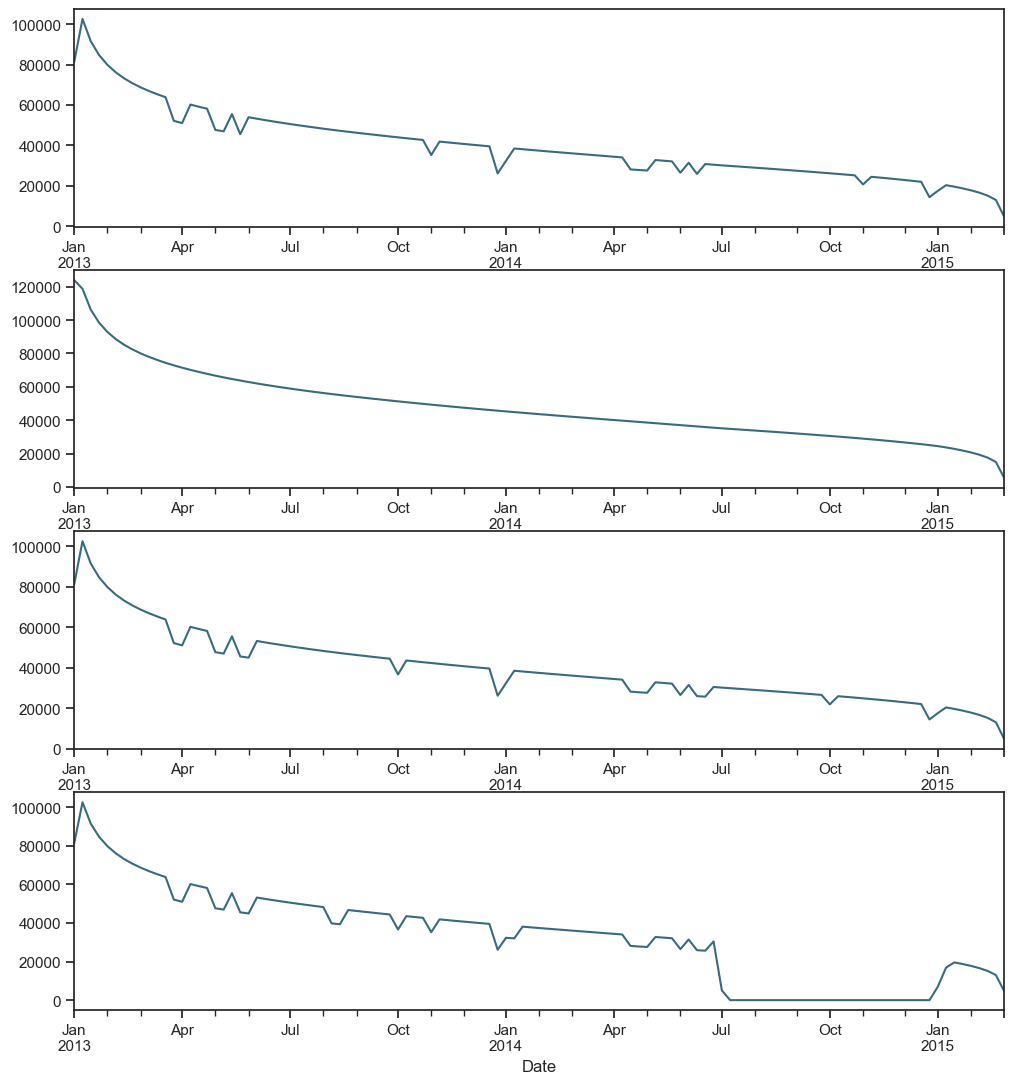

In [43]:
# preparation: input should be float type
train['Sales'] = train['Sales'] * 1.0

# store types
sales_a = train[train.Store == 2]['Sales']
sales_b = train[train.Store == 85]['Sales'].sort_index(ascending = True) # solve the reverse order
sales_c = train[train.Store == 1]['Sales']
sales_d = train[train.Store == 13]['Sales']

f, (ax1, ax2, ax3, ax4) = plt.subplots(4, figsize = (12, 13))

# store types
sales_a.resample('W').sum().plot(color = c, ax = ax1)
sales_b.resample('W').sum().plot(color = c, ax = ax2)
sales_c.resample('W').sum().plot(color = c, ax = ax3)
sales_d.resample('W').sum().plot(color = c, ax = ax4)
plt.show()

### Yearly trend

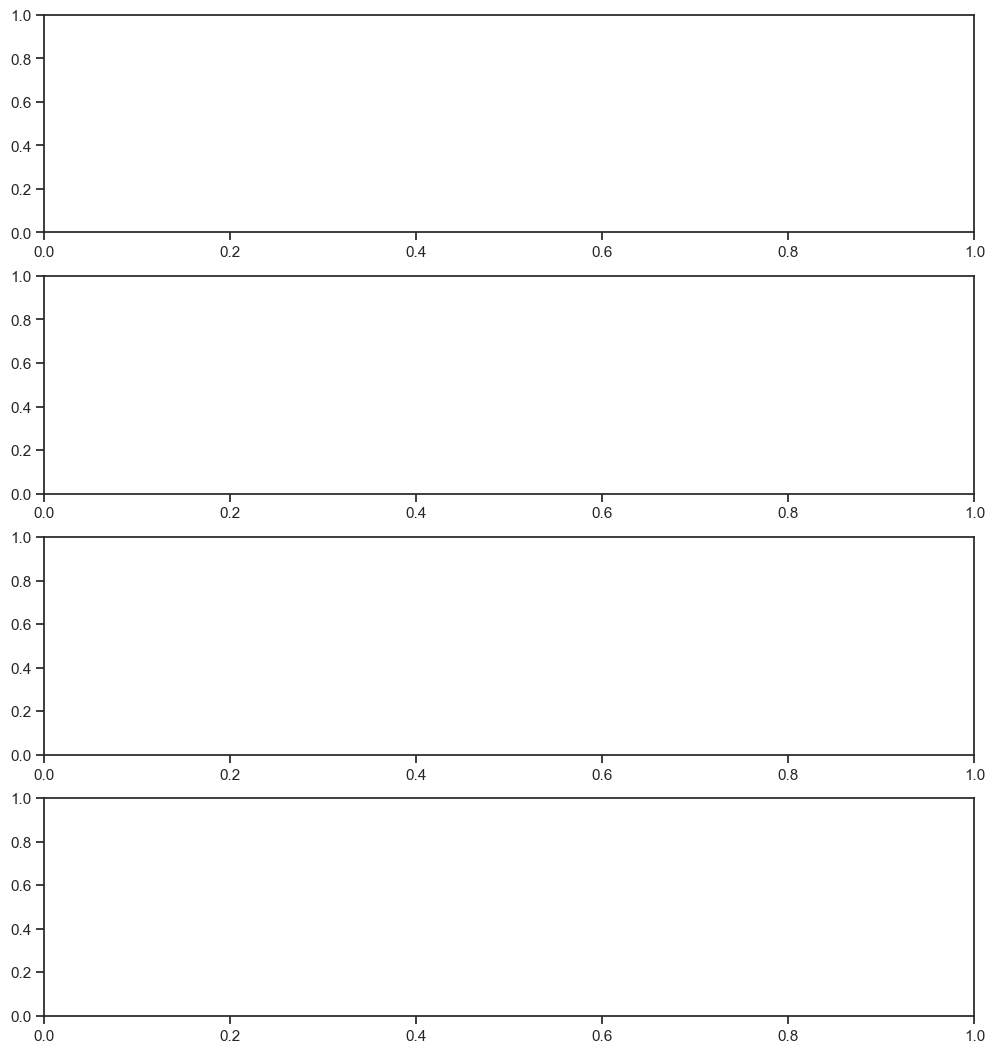

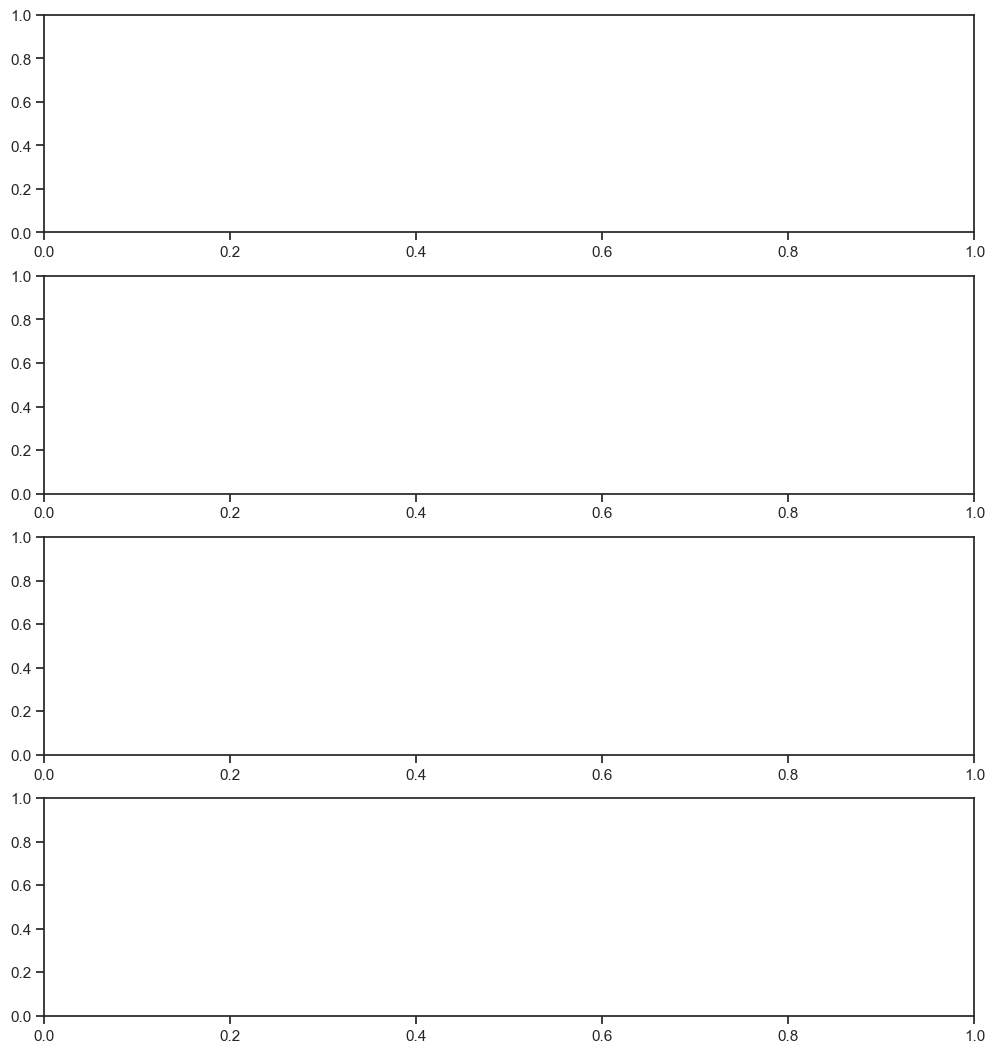

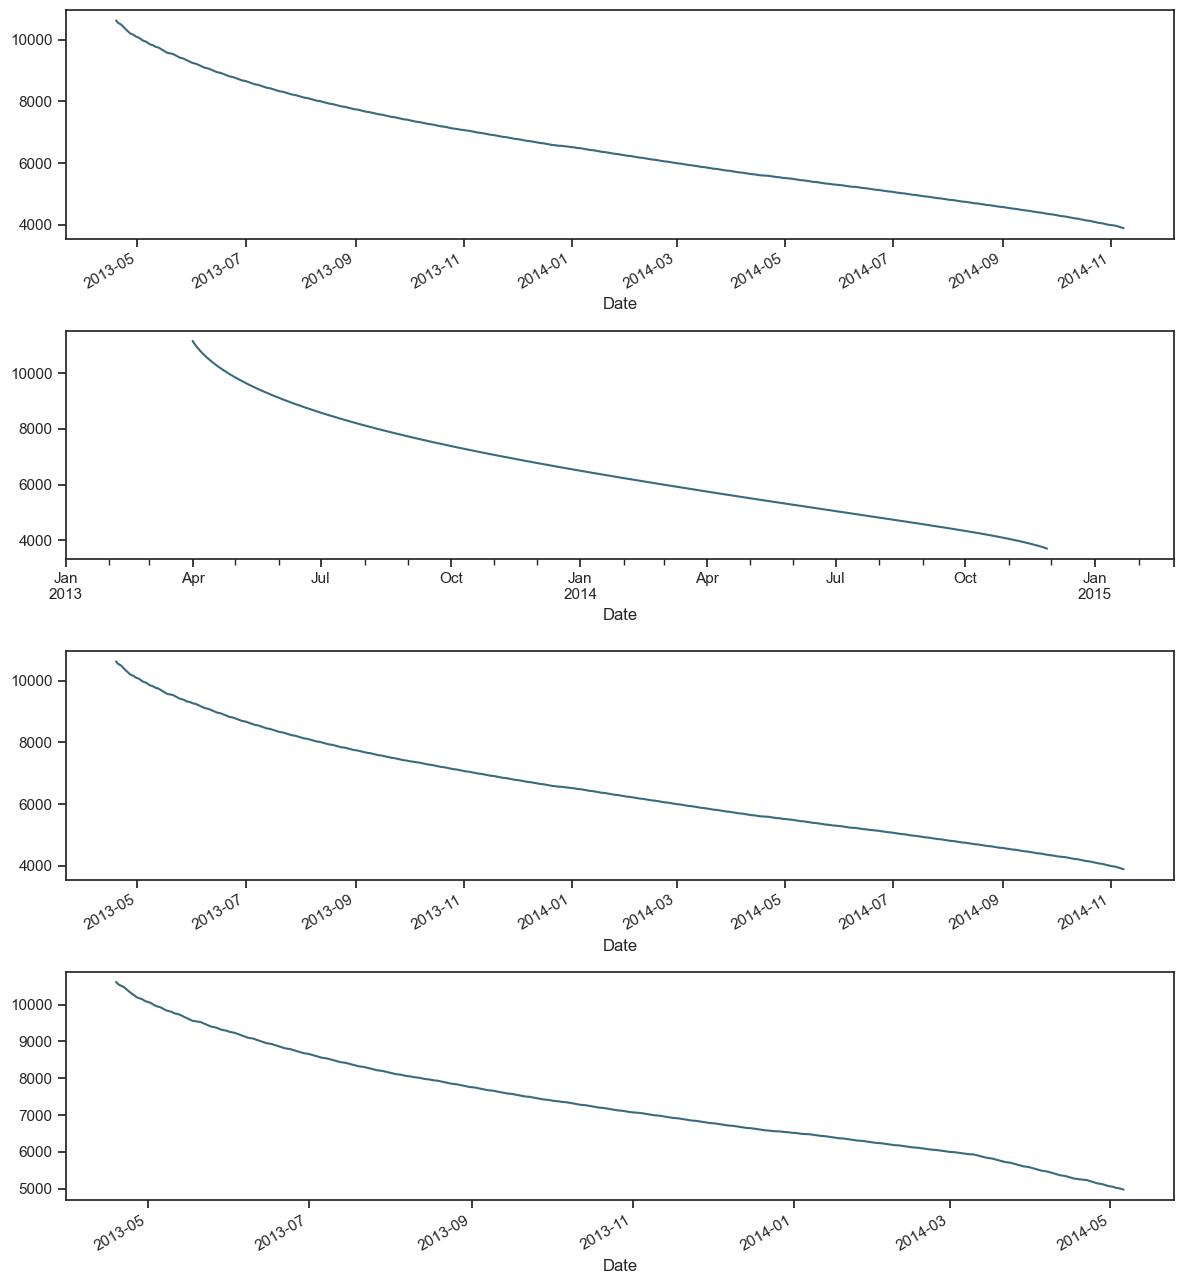

In [46]:
from statsmodels.tsa.seasonal import seasonal_decompose

f, (ax1, ax2, ax3, ax4) = plt.subplots(4, figsize=(12, 13))
c = '#386B7F'

# decomposition for each store type
decomposition_a = seasonal_decompose(sales_a, model='additive', period=180)
decomposition_a.trend.plot(color=c, ax=ax1)

decomposition_b = seasonal_decompose(sales_b, model='additive', period=180)
decomposition_b.trend.plot(color=c, ax=ax2)

decomposition_c = seasonal_decompose(sales_c, model='additive', period=180)
decomposition_c.trend.plot(color=c, ax=ax3)

decomposition_d = seasonal_decompose(sales_d, model='additive', period=180)
decomposition_d.trend.plot(color=c, ax=ax4)

plt.tight_layout()
plt.show()

### Autocorrelaion

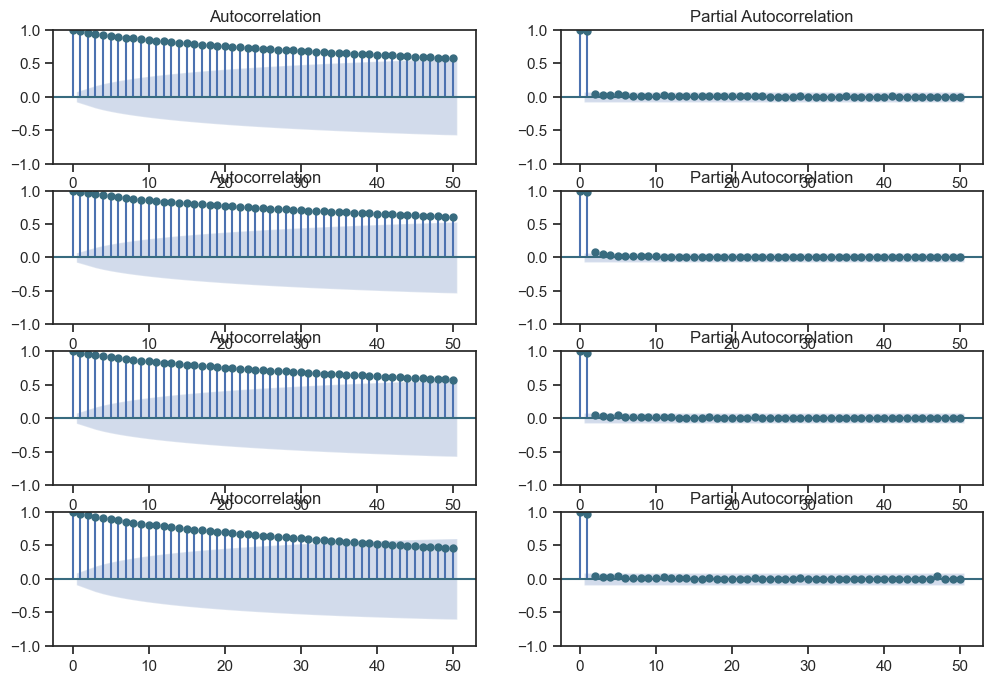

In [47]:
# figure for subplots
plt.figure(figsize = (12, 8))

# acf and pacf for A
plt.subplot(421); plot_acf(sales_a, lags = 50, ax = plt.gca(), color = c)
plt.subplot(422); plot_pacf(sales_a, lags = 50, ax = plt.gca(), color = c)

# acf and pacf for B
plt.subplot(423); plot_acf(sales_b, lags = 50, ax = plt.gca(), color = c)
plt.subplot(424); plot_pacf(sales_b, lags = 50, ax = plt.gca(), color = c)

# acf and pacf for C
plt.subplot(425); plot_acf(sales_c, lags = 50, ax = plt.gca(), color = c)
plt.subplot(426); plot_pacf(sales_c, lags = 50, ax = plt.gca(), color = c)

# acf and pacf for D
plt.subplot(427); plot_acf(sales_d, lags = 50, ax = plt.gca(), color = c)
plt.subplot(428); plot_pacf(sales_d, lags = 50, ax = plt.gca(), color = c)

plt.show()

### Time Series Analysis and Forecasting with Prophet

In [48]:
# importing data
df = pd.read_csv("train.csv",  
                    low_memory = False)

# remove closed stores and those with no sales
df = df[(df["Open"] != 0) & (df['Sales'] != 0)]

# sales for the store number 1 (StoreType C)
sales = df[df.Store == 1].loc[:, ['Date', 'Sales']]

# reverse to the order: from 2013 to 2015
sales = sales.sort_index(ascending = False)

# to datetime64
sales['Date'] = pd.DatetimeIndex(sales['Date'])
sales.dtypes

Date     datetime64[ns]
Sales             int64
dtype: object

In [49]:
# from the prophet documentation every variables should have specific names
sales = sales.rename(columns = {'Date': 'ds',
                                'Sales': 'y'})
sales.head()

,ds,y
1014980,2013-01-02,5530
1013865,2013-01-03,4327
1012750,2013-01-04,4486
1011635,2013-01-05,4997
1009405,2013-01-07,7176


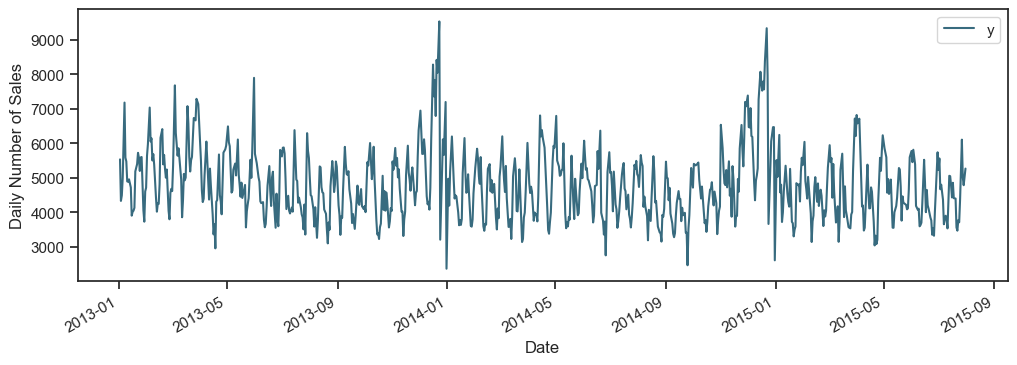

In [50]:
# plot daily sales
ax = sales.set_index('ds').plot(figsize = (12, 4), color = c)
ax.set_ylabel('Daily Number of Sales')
ax.set_xlabel('Date')
plt.show()

### Modeling Holidays

In [51]:
# create holidays dataframe
state_dates = df[(df.StateHoliday == 'a') | (df.StateHoliday == 'b') & (df.StateHoliday == 'c')].loc[:, 'Date'].values
school_dates = df[df.SchoolHoliday == 1].loc[:, 'Date'].values

state = pd.DataFrame({'holiday': 'state_holiday',
                      'ds': pd.to_datetime(state_dates)})
school = pd.DataFrame({'holiday': 'school_holiday',
                      'ds': pd.to_datetime(school_dates)})

holidays = pd.concat((state, school))      
holidays.head()

,holiday,ds
0,state_holiday,2015-06-04
1,state_holiday,2015-06-04
2,state_holiday,2015-06-04
3,state_holiday,2015-06-04
4,state_holiday,2015-06-04


In [52]:
# set the uncertainty interval to 95% (the Prophet default is 80%)
my_model = Prophet(interval_width = 0.95, 
                   holidays = holidays)
my_model.fit(sales)

# dataframe that extends into future 6 weeks 
future_dates = my_model.make_future_dataframe(periods = 6*7)

print("First week to forecast.")
future_dates.tail(7)

10:36:39 - cmdstanpy - INFO - Chain [1] start processing
10:36:41 - cmdstanpy - INFO - Chain [1] done processing


First week to forecast.


,ds
816,2015-09-05
817,2015-09-06
818,2015-09-07
819,2015-09-08
820,2015-09-09
821,2015-09-10
822,2015-09-11


In [53]:
# predictions
forecast = my_model.predict(future_dates)

# preditions for last week
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(7)

,ds,yhat,yhat_lower,yhat_upper
816,2015-09-05,4109.292747,2457.717646,5631.099668
817,2015-09-06,4081.942351,2496.259465,5677.446223
818,2015-09-07,4179.728666,2399.606796,5895.519048
819,2015-09-08,3682.159219,1982.880481,5192.132960
820,2015-09-09,3568.378519,2011.841909,5195.028834
821,2015-09-10,3480.584575,1775.264840,5125.286045
822,2015-09-11,3735.707342,2105.474264,5445.087636


In [54]:
fc = forecast[['ds', 'yhat']].rename(columns = {'Date': 'ds', 'Forecast': 'yhat'})

,ds,yhat,yhat_lower,yhat_upper
0,2013-01-02,5519.800763,3855.001159,7121.985538
1,2013-01-03,5309.677298,3685.272552,6953.132851
2,2013-01-04,5447.630243,3774.986756,7143.743498
3,2013-01-05,5744.196621,4018.414796,7290.415677
4,2013-01-07,5665.331814,3965.982803,7214.361143


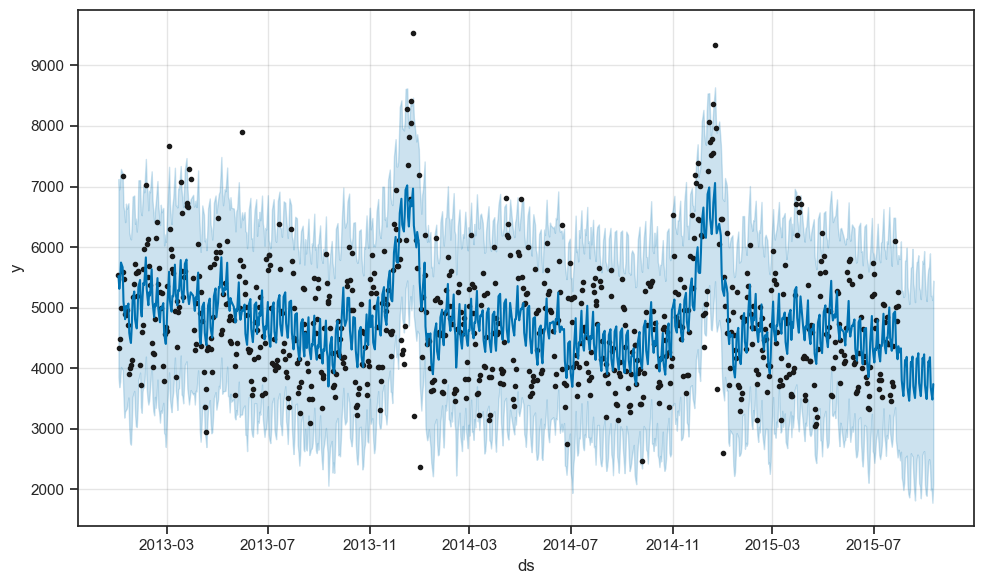

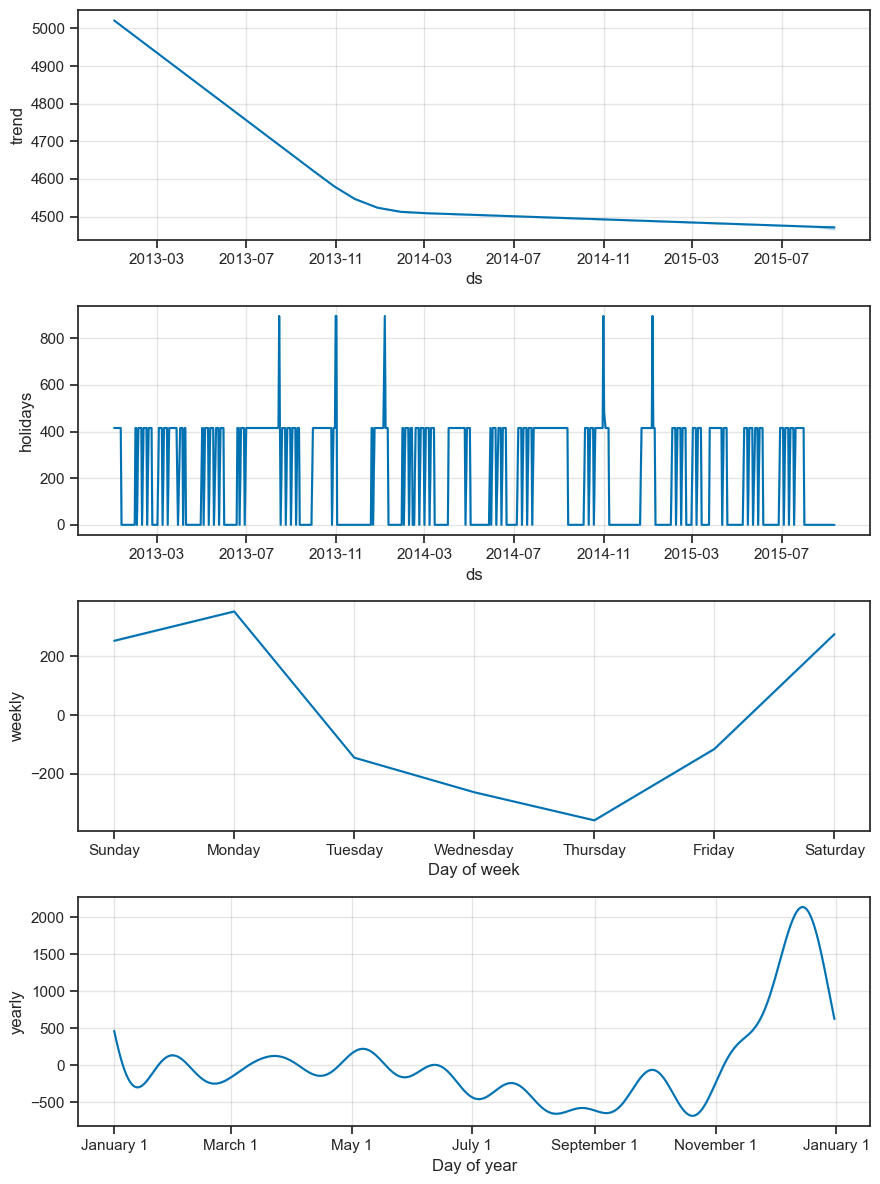

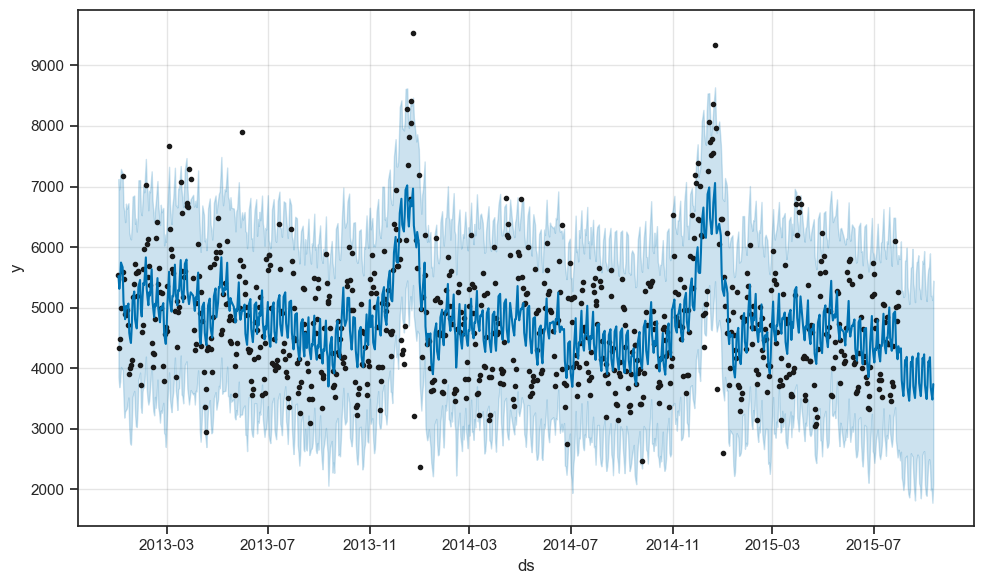

In [57]:
# Tahmin tablosunun ilk birkaç satırı
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

# Grafiği göster
fig1 = my_model.plot(forecast)
plt.show()

,ds,yhat,yhat_lower,yhat_upper
0,2013-01-02,5519.800763,3855.001159,7121.985538
1,2013-01-03,5309.677298,3685.272552,6953.132851
2,2013-01-04,5447.630243,3774.986756,7143.743498
3,2013-01-05,5744.196621,4018.414796,7290.415677
4,2013-01-07,5665.331814,3965.982803,7214.361143


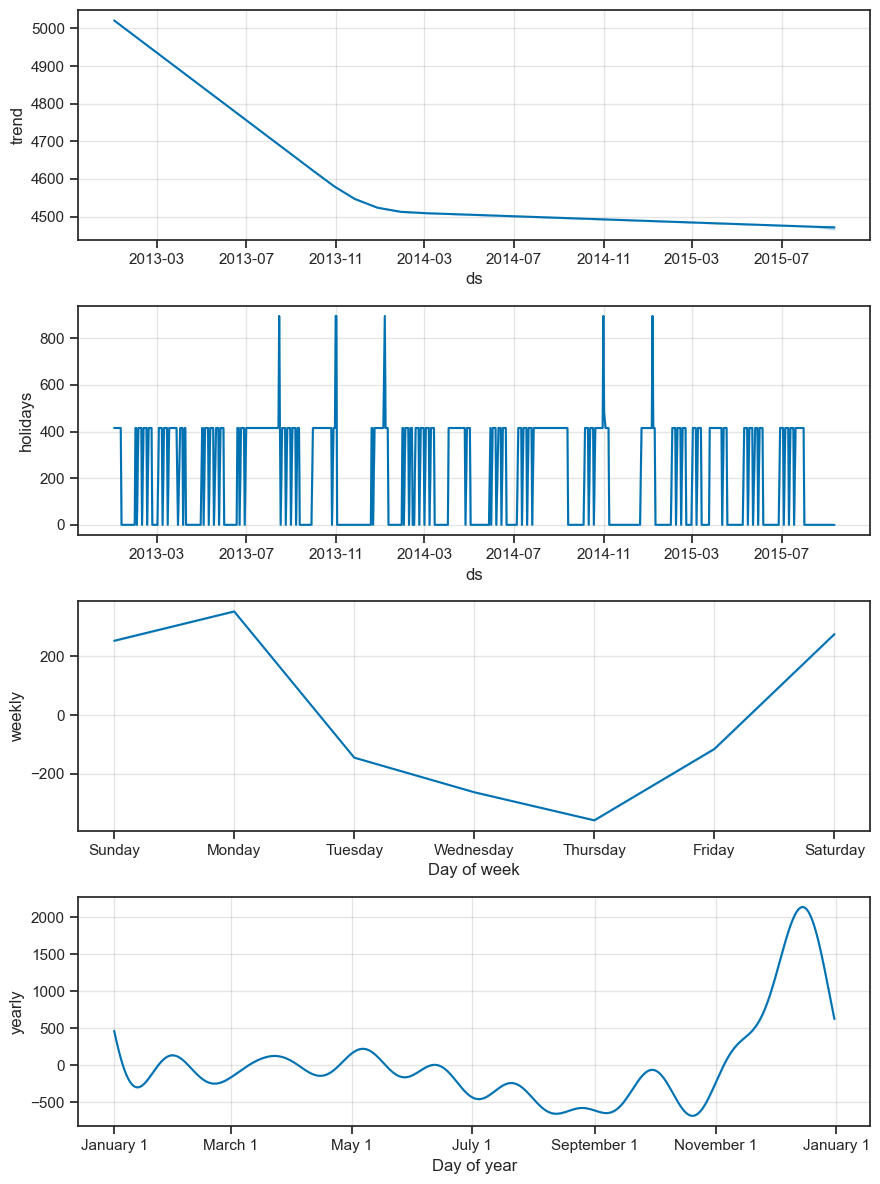

In [58]:
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

# Grafiği göster
fig1 = my_model.plot_components(forecast)
plt.show()


### Summary of Time Series forecasting